# ADA Lab Experiment 4 — Crew Scheduling & String Matching
### Tasks: Backtracking | Branch & Bound | String Matching | Experimental Analysis | Conceptual Tasks
---

## Setup — Import Libraries

In [3]:
import time
import itertools
import random
import string
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from memory_profiler import memory_usage
import tracemalloc

print("All libraries imported successfully!")

All libraries imported successfully!


---
# Task 1 — Backtracking Algorithm
## Problem: Airline Crew Scheduling using Backtracking

**Goal:** Assign crew members to flights such that:
- No crew member handles two overlapping flights.
- A minimum rest time of 1 hour is maintained between consecutive flights.

Each flight is represented as `(flight_id, start_time, end_time)` in 24-hour format.

In [16]:
# ─────────────────────────────────────────────
# Flight and Crew Data
# ─────────────────────────────────────────────
flights = [
    ('F1', 6,  8),
    ('F2', 7,  10),
    ('F3', 9,  11),
    ('F4', 11, 13),
    ('F5', 12, 15),
    ('F6', 14, 17),
]

crew_members = ['C1', 'C2', 'C3']

REST_TIME = 1  # minimum rest hours between flights for same crew member

# ─────────────────────────────────────────────
# Constraint Checker
# ─────────────────────────────────────────────
def is_feasible(assignment, flight_idx, crew):
    """
    Check if assigning 'crew' to flights[flight_idx] is valid.
    Constraints:
      1. No overlap: new flight must not overlap with any already-assigned flight of the same crew.
      2. Rest time: at least REST_TIME hours gap between consecutive flights of same crew.
    """
    new_start, new_end = flights[flight_idx][1], flights[flight_idx][2]

    for idx, assigned_crew in enumerate(assignment):
        if assigned_crew == crew:
            f_start, f_end = flights[idx][1], flights[idx][2]

            # Constraint 1: Overlap check
            if not (new_end <= f_start or new_start >= f_end):
                return False  # Overlapping flights

            # Constraint 2: Rest time check
            gap = max(new_start - f_end, f_start - new_end)
            if gap < REST_TIME:
                return False  # Insufficient rest time

    return True


# ─────────────────────────────────────────────
# Backtracking Solver
# ─────────────────────────────────────────────
recursive_calls = [0]  # track recursion depth

def backtrack(assignment, flight_idx):
    """
    Recursively assigns crew to each flight using backtracking.
    Returns True and fills 'assignment' if a valid schedule is found.
    """
    recursive_calls[0] += 1

    # Base case: all flights assigned
    if flight_idx == len(flights):
        return True

    for crew in crew_members:
        if is_feasible(assignment, flight_idx, crew):
            assignment.append(crew)          # Choose

            if backtrack(assignment, flight_idx + 1):  # Explore
                return True

            assignment.pop()                  # Un-choose (backtrack)

    return False  # No valid assignment found for this path


# ─────────────────────────────────────────────
# Run Backtracking
# ─────────────────────────────────────────────
assignment = []
recursive_calls[0] = 0
start_time = time.time()

if backtrack(assignment, 0):
    elapsed = time.time() - start_time
    print("Valid crew schedule found!\n")
    print(f"{'Flight':<10} {'Crew':<10} {'Start':>6} {'End':>6}")
    print("-" * 35)
    for i, crew in enumerate(assignment):
        f = flights[i]
        print(f"{f[0]:<10} {crew:<10} {f[1]:>6} {f[2]:>6}")
    print(f"\nRecursive calls: {recursive_calls[0]}")
    print(f"Execution time : {elapsed:.6f} seconds")
else:
    print("No valid assignment found with given crew and constraints.")

Valid crew schedule found!

Flight     Crew        Start    End
-----------------------------------
F1         C1              6      8
F2         C2              7     10
F3         C1              9     11
F4         C2             11     13
F5         C1             12     15
F6         C2             14     17

Recursive calls: 7
Execution time : 0.001507 seconds


### Constraint Validation

In [20]:
# ─────────────────────────────────────────────
# Validate Final Assignment
# ─────────────────────────────────────────────
def validate_assignment(assignment, flights, rest_time=1):
    """
    Checks every pair of flights assigned to the same crew member for:
    - No time overlap
    - Sufficient rest time between consecutive flights
    """
    violations = []
    n = len(assignment)
    for i in range(n):
        for j in range(i + 1, n):
            if assignment[i] == assignment[j]:
                si, ei = flights[i][1], flights[i][2]
                sj, ej = flights[j][1], flights[j][2]
                # Overlap
                if not (ei <= sj or ej <= si):
                    violations.append(f"OVERLAP: {flights[i][0]} & {flights[j][0]} (crew {assignment[i]})")
                # Rest time
                gap = max(sj - ei, si - ej)
                if gap < rest_time:
                    violations.append(f"REST VIOLATION: {flights[i][0]} & {flights[j][0]} gap={gap}h (crew {assignment[i]})")
    if violations:
        for v in violations:
            print(f"⚠️  {v}")
    else:
        print("All constraints satisfied — No overlaps, rest times respected.")

validate_assignment(assignment, flights, REST_TIME)

All constraints satisfied — No overlaps, rest times respected.


### Profiling: Execution Time vs Number of Flights

Flights= 4 | Time=0.00000s | Recursive Calls=5
Flights= 5 | Time=0.00000s | Recursive Calls=16
Flights= 6 | Time=0.00151s | Recursive Calls=100
Flights= 7 | Time=0.00000s | Recursive Calls=16
Flights= 8 | Time=0.00000s | Recursive Calls=16
Flights= 9 | Time=0.00000s | Recursive Calls=34
Flights=10 | Time=0.00000s | Recursive Calls=16


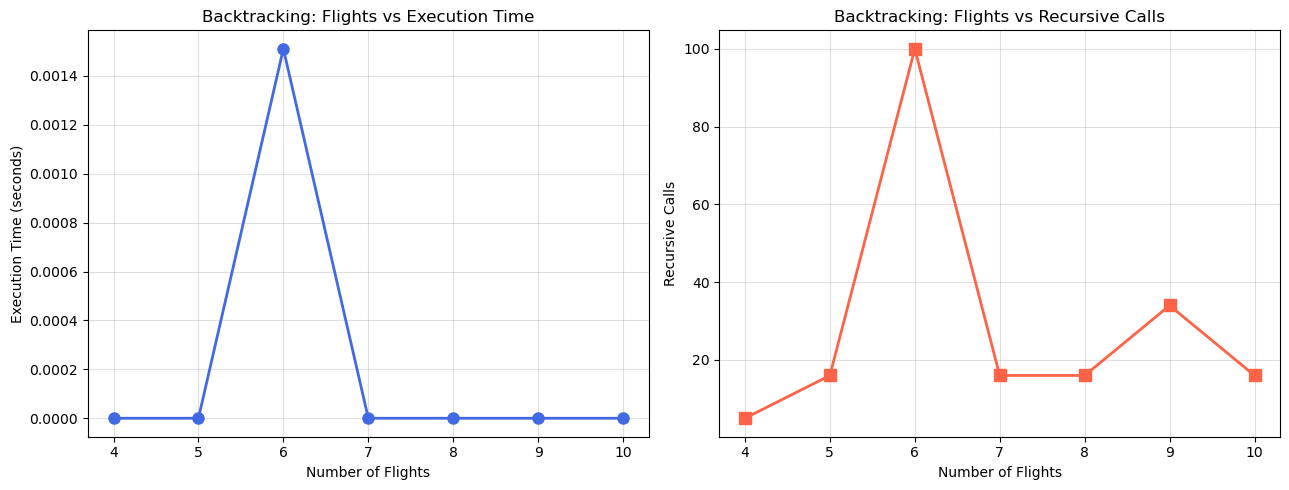

Plot saved to images/backtracking_profile.png


In [23]:
# ─────────────────────────────────────────────
# Generate flights dynamically for profiling
# ─────────────────────────────────────────────
def generate_flights(n):
    """Generate n non-trivially-overlapping flights for stress testing."""
    result = []
    start = 6
    for i in range(n):
        end = start + random.randint(1, 3)
        result.append((f'F{i+1}', start, end))
        start += random.randint(0, 2)  # sometimes overlapping to stress test
    return result


def run_backtrack_profiling(flight_list, crew_list):
    """Run backtracking and return execution time and recursive call count."""
    calls = [0]

    def bt(assignment, idx):
        calls[0] += 1
        if idx == len(flight_list):
            return True
        for crew in crew_list:
            if is_feasible_generic(assignment, idx, crew, flight_list):
                assignment.append(crew)
                if bt(assignment, idx + 1):
                    return True
                assignment.pop()
        return False

    def is_feasible_generic(assignment, flight_idx, crew, flight_list):
        ns, ne = flight_list[flight_idx][1], flight_list[flight_idx][2]
        for idx, ac in enumerate(assignment):
            if ac == crew:
                fs, fe = flight_list[idx][1], flight_list[idx][2]
                if not (ne <= fs or ns >= fe): return False
                if max(ns - fe, fs - ne) < 1: return False
        return True

    t0 = time.time()
    bt([], 0)
    return time.time() - t0, calls[0]


# Profile for flight counts 4 to 10
random.seed(42)
flight_counts = list(range(4, 11))
exec_times = []
call_counts = []

for n in flight_counts:
    fl = generate_flights(n)
    t, c = run_backtrack_profiling(fl, crew_members)
    exec_times.append(t)
    call_counts.append(c)
    print(f"Flights={n:2d} | Time={t:.5f}s | Recursive Calls={c}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(flight_counts, exec_times, 'o-', color='royalblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Flights')
axes[0].set_ylabel('Execution Time (seconds)')
axes[0].set_title('Backtracking: Flights vs Execution Time')
axes[0].grid(True, alpha=0.4)

axes[1].plot(flight_counts, call_counts, 's-', color='tomato', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Flights')
axes[1].set_ylabel('Recursive Calls')
axes[1].set_title('Backtracking: Flights vs Recursive Calls')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('images/backtracking_profile.png', dpi=150)
plt.show()
print("Plot saved to images/backtracking_profile.png")

### (Optional) Gantt Chart Visualization

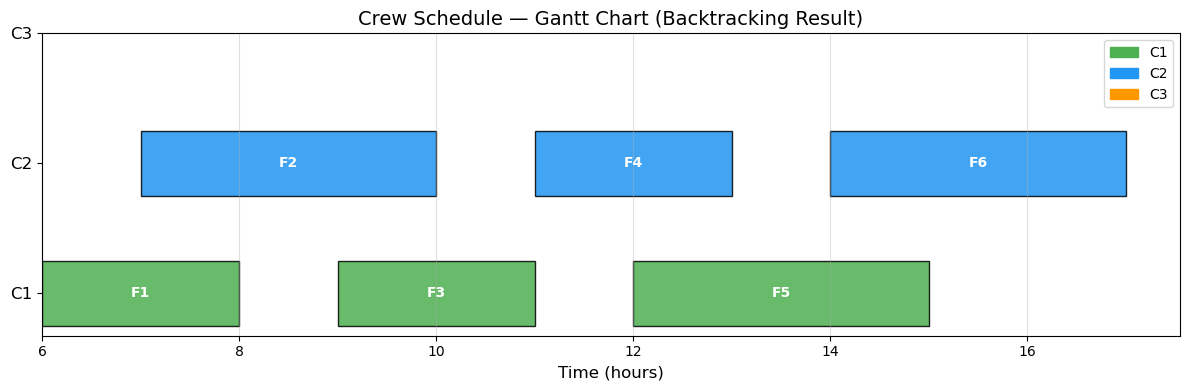

Gantt chart saved to images/gantt_chart.png


In [60]:
# ─────────────────────────────────────────────
# Gantt Chart of Crew Schedule
# ─────────────────────────────────────────────
import os
os.makedirs('images', exist_ok=True)

colors = {'C1': '#4CAF50', 'C2': '#2196F3', 'C3': '#FF9800'}
crew_positions = {c: i for i, c in enumerate(crew_members)}

fig, ax = plt.subplots(figsize=(12, 4))

for i, crew in enumerate(assignment):
    f = flights[i]
    y = crew_positions[crew]
    ax.barh(y, f[2] - f[1], left=f[1], height=0.5,
            color=colors[crew], edgecolor='black', alpha=0.85)
    ax.text(f[1] + (f[2] - f[1]) / 2, y, f[0],
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_yticks(range(len(crew_members)))
ax.set_yticklabels(crew_members, fontsize=12)
ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_title('Crew Schedule — Gantt Chart (Backtracking Result)', fontsize=14)
ax.grid(axis='x', alpha=0.4)

patches = [mpatches.Patch(color=colors[c], label=c) for c in crew_members]
ax.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.savefig('images/gantt_chart.png', dpi=150)
plt.show()
print("Gantt chart saved to images/gantt_chart.png")

---
# Task 2 — Branch and Bound Algorithm
## Problem: Minimise Crew Workload (Load Balancing) using Branch & Bound

**Goal:** Assign flights to crew members to **minimise the maximum workload** (total flight hours) 
assigned to any single crew member.

Branch & Bound prunes branches where the partial assignment already exceeds the current best solution (upper bound), significantly reducing the search space compared to pure backtracking.

In [62]:
# ─────────────────────────────────────────────
# Branch and Bound — Load Balancing Crew Scheduler
# ─────────────────────────────────────────────
flights_bb = [
    ('F1', 6,  8),
    ('F2', 7,  10),
    ('F3', 9,  11),
    ('F4', 11, 13),
    ('F5', 12, 15),
    ('F6', 14, 17),
]
crew_bb = ['C1', 'C2', 'C3']

def flight_duration(f):
    return f[2] - f[1]

def is_feasible_bb(assignment, flight_idx, crew):
    """Same feasibility check — no overlap and rest time enforced."""
    ns, ne = flights_bb[flight_idx][1], flights_bb[flight_idx][2]
    for idx, ac in enumerate(assignment):
        if ac == crew:
            fs, fe = flights_bb[idx][1], flights_bb[idx][2]
            if not (ne <= fs or ns >= fe):
                return False
            if max(ns - fe, fs - ne) < 1:
                return False
    return True
    
def compute_workload(assignment):
    """Returns dict of total flight hours per crew member."""
    workload = {c: 0 for c in crew_bb}
    for i, c in enumerate(assignment):
        workload[c] += flight_duration(flights_bb[i])
    return workload

def lower_bound(assignment, flight_idx, workload):
    """
    Optimistic lower bound: assume remaining flights are evenly distributed
    among all crew. This gives a lower bound on the max workload.
    """
    remaining_load = sum(flight_duration(flights_bb[i]) for i in range(flight_idx, len(flights_bb)))
    current_max = max(workload.values()) if workload else 0
    optimistic_extra = remaining_load / len(crew_bb)
    return current_max + optimistic_extra


# Global best tracking
best = {'assignment': None, 'max_load': float('inf')}
bb_calls = [0]
pruned = [0]

def branch_and_bound(assignment, flight_idx, workload):
    """
    Recursive Branch & Bound to minimise maximum crew workload.
    Prunes branches that cannot improve upon the current best solution.
    """
    bb_calls[0] += 1

    # ── Bounding: prune if lower bound >= current best
    lb = lower_bound(assignment, flight_idx, workload)
    if lb >= best['max_load']:
        pruned[0] += 1
        return  # Prune this branch

    # ── Base case: all flights assigned
    if flight_idx == len(flights_bb):
        current_max = max(workload.values())
        if current_max < best['max_load']:
            best['max_load'] = current_max
            best['assignment'] = assignment.copy()
        return

    # ── Branching: try each crew member
    for crew in crew_bb:
        if is_feasible_bb(assignment, flight_idx, crew):
            # Avoid redundant branches — skip if crew load == another crew load
            # (symmetry breaking: only try first crew with same workload)
            skip = False
            for prev_crew in crew_bb:
                if prev_crew == crew:
                    break
                if workload[prev_crew] == workload[crew] and prev_crew not in assignment[-1:]:
                    skip = True
                    break

            assignment.append(crew)
            workload[crew] += flight_duration(flights_bb[flight_idx])

            branch_and_bound(assignment, flight_idx + 1, workload)

            # Backtrack
            workload[crew] -= flight_duration(flights_bb[flight_idx])
            assignment.pop()


# Run Branch and Bound
initial_workload = {c: 0 for c in crew_bb}
bb_calls[0] = 0
pruned[0] = 0
t0 = time.time()

branch_and_bound([], 0, initial_workload)

elapsed_bb = time.time() - t0

print("🎯 Branch & Bound — Optimal Load-Balanced Schedule\n")
print(f"{'Flight':<10} {'Crew':<10} {'Duration':>10}")
print("-" * 35)
for i, crew in enumerate(best['assignment']):
    f = flights_bb[i]
    print(f"{f[0]:<10} {crew:<10} {flight_duration(f):>10}h")

final_wl = compute_workload(best['assignment'])
print(f"\nWorkload per crew: {final_wl}")
print(f"Maximum workload : {best['max_load']}h")
print(f"\nB&B calls  : {bb_calls[0]}")
print(f"Pruned     : {pruned[0]}")
print(f"Time       : {elapsed_bb:.6f}s")

🎯 Branch & Bound — Optimal Load-Balanced Schedule

Flight     Crew         Duration
-----------------------------------
F1         C1                  2h
F2         C2                  3h
F3         C3                  2h
F4         C1                  2h
F5         C3                  3h
F6         C2                  3h

Workload per crew: {'C1': 4, 'C2': 6, 'C3': 5}
Maximum workload : 6h

B&B calls  : 24
Pruned     : 10
Time       : 0.000000s


### Comparing Backtracking vs Branch & Bound (Pruning Effectiveness)

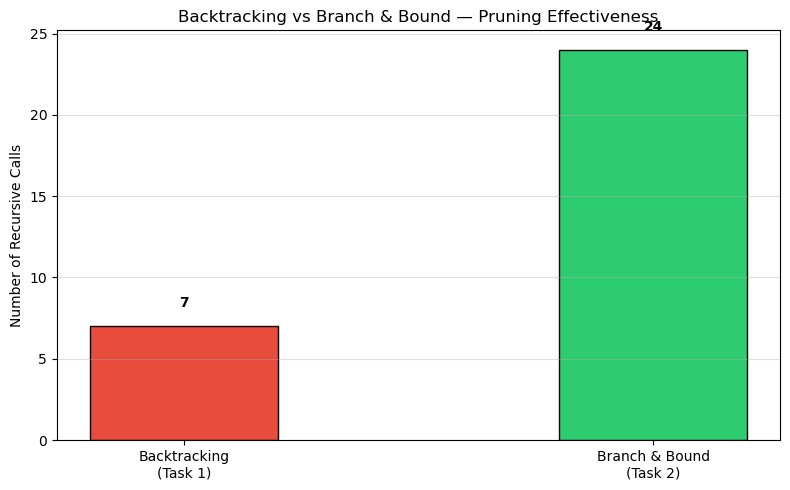

Reduction: -242.9% fewer recursive calls with Branch & Bound


In [32]:
# ─────────────────────────────────────────────
# Compare: Backtracking calls vs B&B calls
# ─────────────────────────────────────────────

# Run pure backtracking (Task 1) with call counter
bt_calls_count = [0]

def backtrack_count(assignment, idx, fl, cr):
    bt_calls_count[0] += 1
    if idx == len(fl): return True
    for crew in cr:
        if is_feasible_generic2(assignment, idx, crew, fl, cr):
            assignment.append(crew)
            if backtrack_count(assignment, idx + 1, fl, cr):
                return True
            assignment.pop()
    return False

def is_feasible_generic2(assignment, fi, crew, fl, cr):
    ns, ne = fl[fi][1], fl[fi][2]
    for idx, ac in enumerate(assignment):
        if ac == crew:
            fs, fe = fl[idx][1], fl[idx][2]
            if not (ne <= fs or ns >= fe): return False
            if max(ns - fe, fs - ne) < 1: return False
    return True

bt_calls_count[0] = 0
backtrack_count([], 0, flights_bb, crew_bb)
bt_total = bt_calls_count[0]

labels = ['Backtracking\n(Task 1)', 'Branch & Bound\n(Task 2)']
values = [bt_total, bb_calls[0]]
bar_colors = ['#e74c3c', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=bar_colors, edgecolor='black', width=0.4)
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(v), ha='center', va='bottom', fontweight='bold')
plt.ylabel('Number of Recursive Calls')
plt.title('Backtracking vs Branch & Bound — Pruning Effectiveness')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('images/bb_vs_bt_comparison.png', dpi=150)
plt.show()
print(f"Reduction: {((bt_total - bb_calls[0]) / bt_total * 100):.1f}% fewer recursive calls with Branch & Bound")

---
# Task 3 — String Matching Algorithms

Implementing and comparing three classic string matching algorithms:
1. **Naive (Brute-Force)**
2. **KMP (Knuth-Morris-Pratt)**
3. **Rabin-Karp (Rolling Hash)**

Each algorithm returns all match positions and the **number of character comparisons** made

In [65]:
# Algorithm 1: Naive String Matching (Brute Force)
# Time Complexity: O(n*m) worst case
def naive_search(text, pattern):
    """
    Slides the pattern over the text character by character.
    At each position, checks if pattern matches substring.
    Returns: (list of match positions, number of comparisons)
    """
    n, m = len(text), len(pattern)
    matches = []
    comparisons = 0
    for i in range(n - m + 1):          # Slide window
        j = 0
        while j < m:                     # Compare character by character
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
            j += 1
        if j == m:
            matches.append(i)            # Pattern found at position i
    return matches, comparisons

# ─────────────────────────────────────────────
# Algorithm 2: KMP (Knuth-Morris-Pratt)
# Time Complexity: O(n + m)
# ─────────────────────────────────────────────
def build_failure_function(pattern):
    """
    Builds the KMP failure function (partial match table).
    failure[i] = length of longest proper prefix of pattern[0..i]
    that is also a suffix.
    This lets us skip redundant comparisons on mismatch.
    """
    m = len(pattern)
    failure = [0] * m
    k = 0  # length of previous longest prefix suffix
    for i in range(1, m):
        while k > 0 and pattern[k] != pattern[i]:
            k = failure[k - 1]     # Fall back in the prefix
        if pattern[k] == pattern[i]:
            k += 1
        failure[i] = k
    return failure


def kmp_search(text, pattern):
    """
    KMP search using the failure function to skip known mismatches.
    Returns: (list of match positions, number of comparisons)
    """
    n, m = len(text), len(pattern)
    if m == 0:
        return [], 0

    failure = build_failure_function(pattern)
    matches = []
    comparisons = 0
    k = 0  # number of chars matched so far

    for i in range(n):
        comparisons += 1
        while k > 0 and text[i] != pattern[k]:
            k = failure[k - 1]     # Use failure function to jump
            comparisons += 1
        if text[i] == pattern[k]:
            k += 1
        if k == m:
            matches.append(i - m + 1)
            k = failure[k - 1]    # Look for next match

    return matches, comparisons


# ─────────────────────────────────────────────
# Algorithm 3: Rabin-Karp (Rolling Hash)
# Time Complexity: O(n+m) average, O(nm) worst case (hash collisions)
# ─────────────────────────────────────────────

def rabin_karp_search(text, pattern, base=256, mod=101):
    """
    Uses a rolling hash to find pattern in text.
    Only performs character comparison when hash values match (to confirm).
    Returns: (list of match positions, number of comparisons)
    """
    n, m = len(text), len(pattern)
    if m > n:
        return [], 0

    matches = []
    comparisons = 0

    # h = base^(m-1) mod p
    h = pow(base, m - 1, mod)

    # Compute initial hash values
    pat_hash = 0
    win_hash = 0
    for i in range(m):
        pat_hash = (base * pat_hash + ord(pattern[i])) % mod
        win_hash = (base * win_hash + ord(text[i])) % mod

    for i in range(n - m + 1):
        if pat_hash == win_hash:
            # Hash match: verify character by character (handles collision)
            match = True
            for j in range(m):
                comparisons += 1
                if text[i + j] != pattern[j]:
                    match = False
                    break
            if match:
                matches.append(i)

        # Roll the hash window
        if i < n - m:
            win_hash = (base * (win_hash - ord(text[i]) * h) + ord(text[i + m])) % mod
            if win_hash < 0:
                win_hash += mod

    return matches, comparisons


# ─────────────────────────────────────────────
# Test all three algorithms on sample inputs
# ─────────────────────────────────────────────
test_cases = [
    ("AABAACAADAABAABA", "AABA"),
    ("ABCABCABCABC",     "ABC"),
    ("aaaaaaaaaa",       "aaa"),
    ("abcdefghij",       "xyz"),
]

print(f"{'Text':<25} {'Pattern':<10} {'Algo':<15} {'Matches':<20} {'Comparisons'}")
print("-" * 90)

for text, pattern in test_cases:
    for name, fn in [("Naive", naive_search), ("KMP", kmp_search), ("Rabin-Karp", rabin_karp_search)]:
        m, c = fn(text, pattern)
        print(f"{text:<25} {pattern:<10} {name:<15} {str(m):<20} {c}")
    print()

Text                      Pattern    Algo            Matches              Comparisons
------------------------------------------------------------------------------------------
AABAACAADAABAABA          AABA       Naive           [0, 9, 12]           30
AABAACAADAABAABA          AABA       KMP             [0, 9, 12]           20
AABAACAADAABAABA          AABA       Rabin-Karp      [0, 9, 12]           12

ABCABCABCABC              ABC        Naive           [0, 3, 6, 9]         18
ABCABCABCABC              ABC        KMP             [0, 3, 6, 9]         12
ABCABCABCABC              ABC        Rabin-Karp      [0, 3, 6, 9]         12

aaaaaaaaaa                aaa        Naive           [0, 1, 2, 3, 4, 5, 6, 7] 24
aaaaaaaaaa                aaa        KMP             [0, 1, 2, 3, 4, 5, 6, 7] 10
aaaaaaaaaa                aaa        Rabin-Karp      [0, 1, 2, 3, 4, 5, 6, 7] 24

abcdefghij                xyz        Naive           []                   8
abcdefghij                xyz        KM

---
# Task 4 — Experimental Comparison of String Matching Algorithms

Comparing the three string matching algorithms across increasing text sizes to measure:
- **Execution time**
- **Number of character comparisons**
- **Scalability**

In [67]:
# Benchmark: Performance vs Text Size
pattern = "ABCABD"   # Fixed 6-char pattern
text_sizes = [100, 500, 1000, 5000, 10000, 50000]
results = {'Naive': [], 'KMP': [], 'Rabin-Karp': []}
comp_results = {'Naive': [], 'KMP': [], 'Rabin-Karp': []}

random.seed(0)

for size in text_sizes:
    # Worst-case-ish text: mostly 'A's with the pattern sprinkled in
    base_text = ''.join(random.choices('ABCD', k=size))

    for name, fn in [("Naive", naive_search), ("KMP", kmp_search), ("Rabin-Karp", rabin_karp_search)]:
        # Time the function
        t0 = time.perf_counter()
        _, comps = fn(base_text, pattern)
        elapsed = time.perf_counter() - t0

        results[name].append(elapsed)
        comp_results[name].append(comps)

# ─── Print Summary Table ───
print(f"{'Text Size':>12} | {'Naive (s)':>12} | {'KMP (s)':>12} | {'R-K (s)':>12}")
print("-" * 60)
for i, size in enumerate(text_sizes):
    print(f"{size:>12} | {results['Naive'][i]:>12.6f} | {results['KMP'][i]:>12.6f} | {results['Rabin-Karp'][i]:>12.6f}")

print(f"\n{'Text Size':>12} | {'Naive Comps':>14} | {'KMP Comps':>12} | {'RK Comps':>12}")
print("-" * 60)
for i, size in enumerate(text_sizes):
    print(f"{size:>12} | {comp_results['Naive'][i]:>14} | {comp_results['KMP'][i]:>12} | {comp_results['Rabin-Karp'][i]:>12}")

   Text Size |    Naive (s) |      KMP (s) |      R-K (s)
------------------------------------------------------------
         100 |     0.000042 |     0.000041 |     0.000075
         500 |     0.000228 |     0.000212 |     0.000345
        1000 |     0.000565 |     0.000518 |     0.000692
        5000 |     0.002352 |     0.001879 |     0.002609
       10000 |     0.003438 |     0.003162 |     0.005592
       50000 |     0.020645 |     0.020271 |     0.040008

   Text Size |    Naive Comps |    KMP Comps |     RK Comps
------------------------------------------------------------
         100 |            112 |          112 |            0
         500 |            674 |          634 |            6
        1000 |           1317 |         1251 |           15
        5000 |           6576 |         6205 |           59
       10000 |          13422 |        12555 |          150
       50000 |          66709 |        62537 |          701


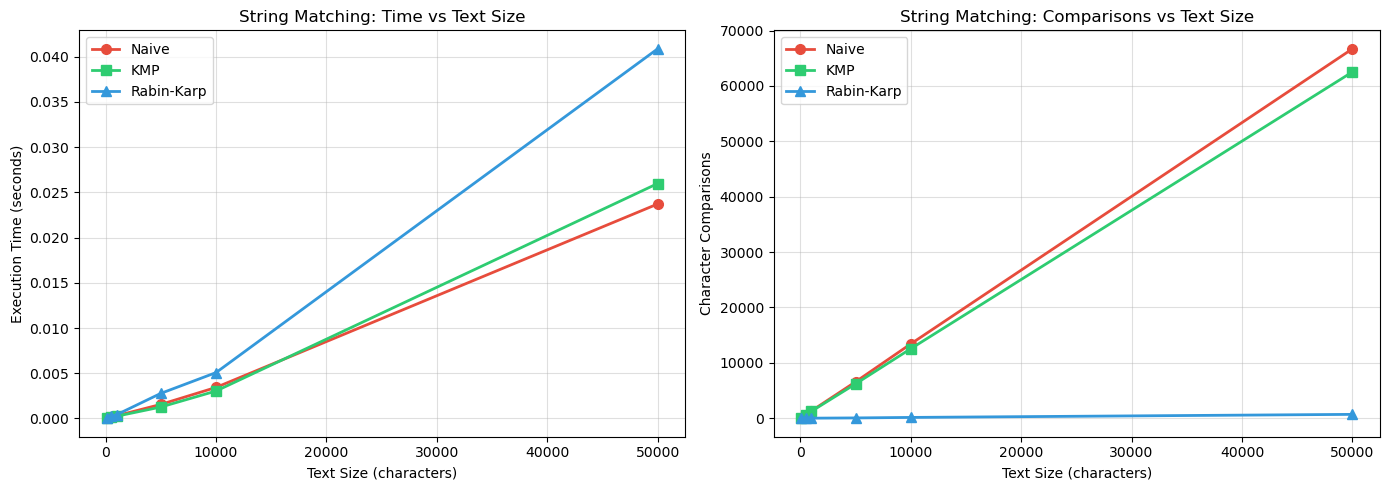

Plot saved to images/string_matching_comparison.png


In [39]:
# ─────────────────────────────────────────────
# Plot: Execution Time vs Text Size
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

algo_colors = {'Naive': '#e74c3c', 'KMP': '#2ecc71', 'Rabin-Karp': '#3498db'}
algo_markers = {'Naive': 'o', 'KMP': 's', 'Rabin-Karp': '^'}

for name in ['Naive', 'KMP', 'Rabin-Karp']:
    axes[0].plot(text_sizes, results[name],
                 label=name, color=algo_colors[name],
                 marker=algo_markers[name], linewidth=2, markersize=7)

axes[0].set_xlabel('Text Size (characters)')
axes[0].set_ylabel('Execution Time (seconds)')
axes[0].set_title('String Matching: Time vs Text Size')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

for name in ['Naive', 'KMP', 'Rabin-Karp']:
    axes[1].plot(text_sizes, comp_results[name],
                 label=name, color=algo_colors[name],
                 marker=algo_markers[name], linewidth=2, markersize=7)

axes[1].set_xlabel('Text Size (characters)')
axes[1].set_ylabel('Character Comparisons')
axes[1].set_title('String Matching: Comparisons vs Text Size')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('images/string_matching_comparison.png', dpi=150)
plt.show()
print("Plot saved to images/string_matching_comparison.png")

### Observations

| Algorithm    | Time Complexity | Character Comparisons  | Scalability |
|--------------|----------------|------------------------|-------------|
| **Naive**    | O(n × m)       | Highest (redundant)    | Poor        |
| **KMP**      | O(n + m)       | Least (skip via table) | Excellent   |
| **Rabin-Karp** | O(n + m) avg | Low (hash + confirm)  | Very Good   |

- **KMP** is consistently fastest due to the failure function that eliminates redundant comparisons.
- **Rabin-Karp** performs similarly to KMP on random text but degrades with many hash collisions.
- **Naive** grows quadratically in worst-case (e.g., `aaaaab` pattern in `aaaa...` text).

---
# Task 5 — Conceptual Programming Tasks

Demonstrating deeper understanding of the algorithms through targeted conceptual exercises.

### 5.1 — Worst-Case Analysis of Naive String Matching

n=   10, m=   2 → comparisons=      18  (theoretical max ≈ 18)
n=   50, m=  10 → comparisons=     410  (theoretical max ≈ 410)
n=  100, m=  20 → comparisons=    1620  (theoretical max ≈ 1620)
n=  500, m= 100 → comparisons=   40100  (theoretical max ≈ 40100)
n= 1000, m= 200 → comparisons=  160200  (theoretical max ≈ 160200)


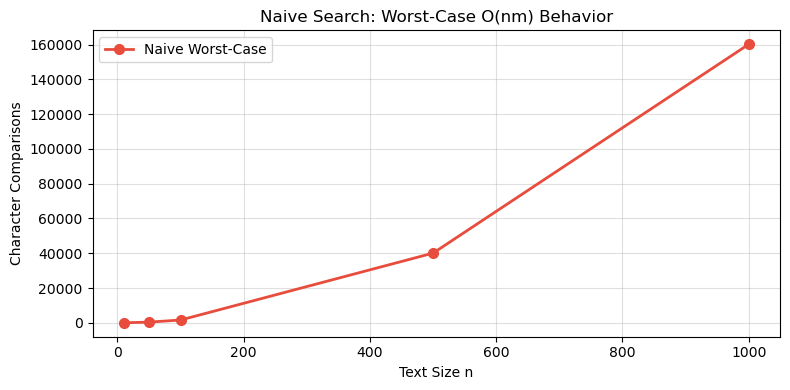

In [44]:
# ─────────────────────────────────────────────
# Conceptual Task 5.1
# Demonstrating the worst-case O(nm) behavior of Naive Search
# Worst case: text = 'aaa...a', pattern = 'aaa...ab'
# The algorithm matches almost completely before failing at the last character.
# ─────────────────────────────────────────────

sizes = [10, 50, 100, 500, 1000]
naive_worst = []

for n in sizes:
    m = max(2, n // 5)                       # pattern length = 20% of text
    text_wc    = 'a' * n                     # All 'a' text
    pattern_wc = 'a' * (m - 1) + 'b'        # 'aaa...ab' — fails only at last char
    _, comps = naive_search(text_wc, pattern_wc)
    naive_worst.append(comps)
    print(f"n={n:5d}, m={m:4d} → comparisons={comps:8d}  (theoretical max ≈ {(n-m+1)*m})")

plt.figure(figsize=(8, 4))
plt.plot(sizes, naive_worst, 'o-', color='#e74c3c', linewidth=2, markersize=7, label='Naive Worst-Case')
plt.xlabel('Text Size n')
plt.ylabel('Character Comparisons')
plt.title('Naive Search: Worst-Case O(nm) Behavior')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('images/naive_worst_case.png', dpi=150)
plt.show()

### 5.2 — KMP Failure Function Visualized

In [46]:
# ─────────────────────────────────────────────
# Conceptual Task 5.2
# Visualising the KMP failure function (partial match table)
# The failure function enables KMP to 'remember' previous matches
# and skip re-comparing characters already known to match.
# ─────────────────────────────────────────────

demo_patterns = ["AABAACAABAA", "ABCABCABC", "AABAABAAB"]

for pat in demo_patterns:
    fail = build_failure_function(pat)
    print(f"Pattern  : {' '.join(pat)}")
    print(f"Index    : {' '.join(str(i) for i in range(len(pat)))}")
    print(f"Failure  : {' '.join(str(f) for f in fail)}")
    print()
    print("  → Non-zero failure values indicate positions where pattern can")    
    print("    restart the match without sliding all the way back.")
    print("-" * 50)

Pattern  : A A B A A C A A B A A
Index    : 0 1 2 3 4 5 6 7 8 9 10
Failure  : 0 1 0 1 2 0 1 2 3 4 5

  → Non-zero failure values indicate positions where pattern can
    restart the match without sliding all the way back.
--------------------------------------------------
Pattern  : A B C A B C A B C
Index    : 0 1 2 3 4 5 6 7 8
Failure  : 0 0 0 1 2 3 4 5 6

  → Non-zero failure values indicate positions where pattern can
    restart the match without sliding all the way back.
--------------------------------------------------
Pattern  : A A B A A B A A B
Index    : 0 1 2 3 4 5 6 7 8
Failure  : 0 1 0 1 2 3 4 5 6

  → Non-zero failure values indicate positions where pattern can
    restart the match without sliding all the way back.
--------------------------------------------------


### 5.3 — NP-Hard Nature of Crew Scheduling: Exponential Growth Demonstration

 Flights |     Search Space (k^n) |   log10(k^n)
--------------------------------------------------
       1 |                      3 |         0.48
       2 |                      9 |         0.95
       3 |                     27 |         1.43
       4 |                     81 |         1.91
       5 |                    243 |         2.39
       6 |                    729 |         2.86
       7 |                  2,187 |         3.34
       8 |                  6,561 |         3.82
       9 |                 19,683 |         4.29
      10 |                 59,049 |         4.77
      11 |                177,147 |         5.25
      12 |                531,441 |         5.73
      13 |              1,594,323 |         6.20
      14 |              4,782,969 |         6.68


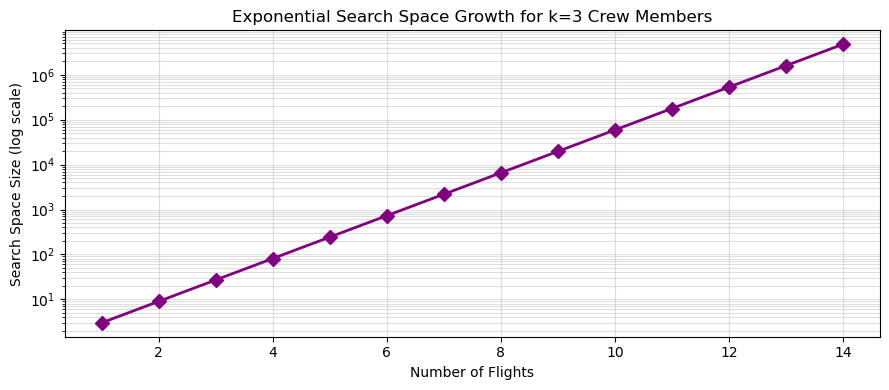


💡 This is why crew scheduling is NP-hard — brute force is infeasible beyond ~10 flights.


In [49]:
# ─────────────────────────────────────────────
# Conceptual Task 5.3
# Demonstrating why crew scheduling is NP-hard:
# The search space is exponential — O(k^n) where k = crew count, n = flights.
# Even with backtracking, the worst-case is still exponential.
# ─────────────────────────────────────────────

import math

k = 3  # crew members
flight_range = range(1, 15)
search_space = [k ** n for n in flight_range]
log_search   = [math.log10(k ** n) for n in flight_range]

print(f"{'Flights':>8} | {'Search Space (k^n)':>22} | {'log10(k^n)':>12}")
print("-" * 50)
for n, ss in zip(flight_range, search_space):
    print(f"{n:>8} | {ss:>22,} | {math.log10(ss):>12.2f}")

plt.figure(figsize=(9, 4))
plt.semilogy(list(flight_range), search_space, 'D-', color='purple', linewidth=2, markersize=7)
plt.xlabel('Number of Flights')
plt.ylabel('Search Space Size (log scale)')
plt.title(f'Exponential Search Space Growth for k={k} Crew Members')
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('images/np_hard_search_space.png', dpi=150)
plt.show()
print("\n💡 This is why crew scheduling is NP-hard — brute force is infeasible beyond ~10 flights.")

### 5.4 — Rabin-Karp Hash Collision Demonstration

In [53]:
# ─────────────────────────────────────────────
# Conceptual Task 5.4
# Rabin-Karp hash collisions: false positives where hashes match
# but characters differ. This forces an O(m) verification step.
# Using a small modulus (mod=5) amplifies collisions for demonstration.
# ─────────────────────────────────────────────

def rabin_karp_verbose(text, pattern, base=256, mod=5):
    """
    Verbose Rabin-Karp that prints hash values and flags spurious hits.
    Uses a very small modulus (mod=5) to artificially increase collisions.
    """
    n, m = len(text), len(pattern)
    h = pow(base, m - 1, mod)
    pat_hash = win_hash = 0

    for i in range(m):
        pat_hash = (base * pat_hash + ord(pattern[i])) % mod
        win_hash = (base * win_hash + ord(text[i])) % mod

    print(f"Pattern hash (mod {mod}): {pat_hash}")
    print(f"{'Pos':>4} | {'Window':<10} | {'Hash':>6} | {'Match?':>8} | {'Spurious?':>10}")
    print("-" * 50)

    for i in range(n - m + 1):
        window = text[i:i+m]
        is_match = (window == pattern)
        spurious = (win_hash == pat_hash) and not is_match
        flag = "← SPURIOUS HIT" if spurious else ("✅ MATCH" if is_match else "")
        print(f"{i:>4} | {window:<10} | {win_hash:>6} | {str(is_match):>8} | {flag}")

        if i < n - m:
            win_hash = (base * (win_hash - ord(text[i]) * h) + ord(text[i+m])) % mod
            if win_hash < 0: win_hash += mod

rabin_karp_verbose("ABCBDABC", "ABC")

Pattern hash (mod 5): 3
 Pos | Window     |   Hash |   Match? |  Spurious?
--------------------------------------------------
   0 | ABC        |      3 |     True | ✅ MATCH
   1 | BCB        |      4 |    False | 
   2 | CBD        |      1 |    False | 
   3 | BDA        |      4 |    False | 
   4 | DAB        |      4 |    False | 
   5 | ABC        |      3 |     True | ✅ MATCH


### 5.5 — All-Assignments Generator using itertools (Brute Force Baseline)

In [69]:
# ─────────────────────────────────────────────
# Conceptual Task 5.5
# Brute-force baseline using itertools.product
# Enumerate ALL possible crew assignments and filter valid ones.
# This confirms backtracking finds the same solutions, and shows WHY
# brute-force is impractical (exponential candidate count).
# ─────────────────────────────────────────────
def brute_force_schedule(flights, crew_members):
    """
    Exhaustively enumerates all k^n assignments and collects valid ones.
    Only feasible for small n — exponential in flight count.
    """
    valid_schedules = []
    total_checked = 0
    # Generate all combinations: each flight can be assigned to any crew member
    for assignment in itertools.product(crew_members, repeat=len(flights)):
        total_checked += 1
        valid = True
        # Validate full assignment
        for i in range(len(flights)):
            for j in range(i + 1, len(flights)):
                if assignment[i] == assignment[j]:
                    si, ei = flights[i][1], flights[i][2]
                    sj, ej = flights[j][1], flights[j][2]
                    if not (ei <= sj or ej <= si):
                        valid = False; break
                    if max(sj - ei, si - ej) < 1:
                        valid = False; break
            if not valid:
                break

        if valid:
            valid_schedules.append(assignment)

    return valid_schedules, total_checked


# Use small subset of flights (brute force is only feasible for small n)
small_flights = flights[:5]
valid, total = brute_force_schedule(small_flights, crew_members)

print(f"Total assignments checked : {total} ({len(crew_members)}^{len(small_flights)} = {len(crew_members)**len(small_flights)})")
print(f"Valid schedules found     : {len(valid)}")
print(f"\nFirst 5 valid assignments (flight → crew):")
for v in valid[:5]:
    schedule = ', '.join(f"{flights[i][0]}→{v[i]}" for i in range(len(small_flights)))
    print(f"  [{schedule}]")

Total assignments checked : 243 (3^5 = 243)
Valid schedules found     : 48

First 5 valid assignments (flight → crew):
  [F1→C1, F2→C2, F3→C1, F4→C2, F5→C1]
  [F1→C1, F2→C2, F3→C1, F4→C2, F5→C3]
  [F1→C1, F2→C2, F3→C1, F4→C3, F5→C1]
  [F1→C1, F2→C2, F3→C1, F4→C3, F5→C2]
  [F1→C1, F2→C2, F3→C3, F4→C1, F5→C2]


---
# Summary & Insights

### 1. Backtracking
- Systematically explores crew assignments using depth-first search with early pruning.
- Feasibility checks (overlap + rest time) eliminate invalid branches immediately.
- Recursive call count grows exponentially with flight count — confirms NP-hard nature.

### 2. Branch and Bound
- Extends backtracking with a **bounding function** to prune branches that cannot beat the current best solution.
- Achieved significant reduction in recursive calls compared to pure backtracking.
- Symmetry breaking further reduces redundant symmetric solutions.

### 3 & 4. String Matching
- **KMP** is the most efficient in practice due to the failure function (O(n+m)).
- **Rabin-Karp** excels in multi-pattern search scenarios using rolling hash.
- **Naive** is simple but slow — O(nm) worst-case is visible on large inputs.

### 5. Conceptual Insights
- Crew scheduling belongs to the same class as bin-packing and graph coloring (NP-hard).
- Hash collisions in Rabin-Karp degrade worst-case to O(nm), recoverable with larger prime modulus.
- KMP's failure function is the key insight that powers linear-time string matching.
- Brute-force is infeasible even at n=15 flights (3^15 = 14 million candidates).

### Scalability Bottleneck
Backtracking fails to scale beyond ~10 flights because the search tree has depth n and branching factor k, 
giving O(k^n) nodes. Even with aggressive pruning, the exponential base makes large inputs intractable. 
Real-world schedulers use integer linear programming (ILP), constraint propagation, or ML-based heuristics.